# Tandem AoI simulation: paper-focused deterministic heterogeneous figures

This notebook is the paper-facing experiment driver for the tandem AoI simulator. The reusable math, simulator dynamics, policy implementations, diagnostics, and plotting helpers live in the `tandem/` package.

The main figures emphasize aggressive deterministic heterogeneous networks with raw, unnormalized source weights. The goal is to compare certificate-guided Joint FGMW, the lambda-aware isolated MW reference, target-rate-debt DA-MW, Greedy, and the two stationary randomized SRP baselines under aligned and conflict weight-channel pairings.

Older homogeneous anchor and debugging checks are not part of the main story; minimal sanity checks are kept only in the appendix-style section near the end.


In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tandem.config import make_symmetric_network
from tandem.diagnostics import estimate_iso1_voq_arrival_rates, paired_replications, validate_run_result
from tandem.policies import (
    ComposedV3,
    GreedyBSV3,
    GreedyESV3,
    IsoBSV3,
    IsoESV3,
    JointBSV3,
    JointESV3,
    SRPBSV3,
    TheoremSRPESV3,
    UniformBSV3,
    UniformESV3,
    WorkConservingSRPESV3,
    build_experiment_v3,
    build_iso1_iso2_lambda_policy_v3,
    build_srp_iso_policy_v3,
    build_srp_tandem_lb_policy_v3,
    build_policies_v3,
)
from tandem.rate_optimizer import (
    iso1_params_v3,
    iso2_lambda_params_v3,
    iso2_params_v3,
    joint_params_v3,
    lb_bsside_v3,
    lb_dest_iso2_relaxed_v3,
    lb_dest_joint_v3,
    solve_capped_edge_rate_kkt,
    solve_rate_kkt,
)
from tandem.simulator import TandemAoISimulatorV3
from tandem import plotting as tandem_plotting

%matplotlib inline
np.set_printoptions(precision=6, suppress=True)


## 1. Convex rate programs and Lyapunov coefficients

The common rate objective is

\[
\min_{q_i>0}\sum_i\left(\frac{w_i}{2q_i}+g_iq_i\right),
\]

with an optional Stage-1 constraint

\[
\sum_i\left(L-1+\frac{1}{p_i}\right)q_i\le 1
\]

and an optional Stage-2 constraint $\sum_iq_i\le\mu$. The KKT form is

\[
q_i=\sqrt{\frac{w_i}{2(g_i+\lambda c_i+\nu)}}.
\]

The implementation below solves for the nonnegative multipliers by nested monotone bisection and verifies
primal feasibility and stationarity before returning any coefficients.


In [2]:
# =====================================================================
# Reliable convex rate solver
# =====================================================================
# Reusable optimizer code now lives in tandem.rate_optimizer and is imported above.


## 2. Corrected tandem simulator

A slot first reads the beginning-of-slot state and makes eligible Stage-1/Stage-2 decisions, then realizes
the gate and service coins, and finally constructs the next-slot state. A Stage-1 arrival generated in slot
$k$ cannot be selected by Stage 2 until slot $k+1$.

The measured event rates and resource fractions below are all based on exactly the same post-warmup slots as
the AoI averages. Lifetime counters are retained separately for finite-horizon conservation checks.


In [3]:
# =====================================================================
# Corrected simulator and diagnostics
# =====================================================================
# Reusable simulator dynamics now live in tandem.simulator.
# Post-warmup accounting helpers live in tandem.diagnostics.


## 3. Composable policy layer

The joint and isolated policies are assembled from independent Stage-1 and Stage-2 controllers. Random ties
are broken without source-index bias. Two randomized Stage-2 baselines are retained:

- **theorem-SRP2:** sample from all sources and idle when the sampled VOQ is empty;
- **WC-SRP2:** renormalize over currently nonempty VOQs, isolating age-blind prioritization from avoidable idling.

For $L=1$, the simulator remains valid, but the supplied $L>1$ FGMW derivations are not automatically claimed;
`build_policies_v3` rejects that case unless the empirical extension is explicitly enabled.


In [4]:
# =====================================================================
# Controllers with stage-specific policy RNG and unbiased tie-breaking
# =====================================================================
# Reusable policy classes and experiment builders now live in tandem.policies.


## 8. Aggressive deterministic heterogeneous sweeps

This is the main paper-facing sweep figure. It keeps the embedded 2x3 multi-axis sweep style, but uses the deterministic aggressive heterogeneous stress case. The base weights are raw and unnormalized: $w=[8,4,2,1,0.5,0.25,0.125,0.0625]$. The base channel levels are $[0.95,0.85,0.70,0.55,0.40,0.28,0.18,0.10]$.

The embedded sweep uses `det_conflict`: high-weight sources are intentionally paired with bad channels. This deterministic setup avoids random-sampling ambiguity and keeps the weighted-AoI objective intentionally aggressive.

The main figure plots the actual weighted destination AoI objective for each policy against the black joint/universal lower-bound curve. This is the paper-facing view: it shows objective values and their distance from the lower bound directly.

Policies shown: Joint FGMW, `iso1 + iso2-lambda`, Downstream-Aware MW, Greedy, `SRP-iso`, and `SRP-tandem-LB`.

`RECOMPUTE_SWEEPS` remains `False`; the notebook renders from the embedded arrays and does not rerun simulations.


In [5]:
SWEEP_V3_JSON = r'''{"p":{"x":[0.5,0.65,0.8,0.95,1.1,1.25],"xlabel":"det_conflict channel scale applied to p_i","policies":{"Joint FGMW":[741.8404282407407,616.7079282407408,542.4913078703704,494.5888541666667,470.51738425925925,435.5846759259259],"iso1 + iso2-lambda":[747.3908680555555,608.3490509259259,561.925300925926,497.13903935185186,455.7161458333333,439.63131944444444],"Downstream-Aware MW":[727.059675925926,613.8918171296297,536.8006597222222,492.64386574074075,456.0503356481481,424.6133564814815],"Greedy":[788.4656365740741,682.493425925926,625.8877430555556,600.0328935185186,565.4714467592593,561.3262962962963],"SRP-iso":[1050.7478125,867.8205439814815,854.2100347222222,722.7594097222222,656.3451041666667,616.0064930555556],"SRP-tandem-LB":[1053.9886921296297,879.0261921296296,829.7250925925925,731.3627314814814,667.1865856481481,635.3270717592593]},"lb":[569.7050592358329,476.69777162206174,418.6671784246708,379.04170777095663,350.3600327648029,328.8766113076826]},"L":{"x":[2,3,4,5,6,8],"xlabel":"Stage-1 length L","policies":{"Joint FGMW":[431.69104166666665,486.5267361111111,525.7861689814815,572.1679050925926,638.3285763888889,750.8815162037037],"iso1 + iso2-lambda":[430.9921412037037,477.58081018518516,543.5804861111111,586.6293518518519,648.860462962963,778.6034143518518],"Downstream-Aware MW":[430.8010300925926,477.6139351851852,536.6778819444445,565.7244328703704,623.3034953703703,733.3197453703704],"Greedy":[566.7950694444445,584.761099537037,600.0610069444444,652.7585763888889,734.7756828703704,860.0228472222223],"SRP-iso":[619.2226273148148,681.5789467592592,778.9564236111111,888.1180671296296,927.6237037037037,1103.5208680555556],"SRP-tandem-LB":[610.727037037037,678.3433449074074,781.4583912037037,882.2775462962964,916.991712962963,1086.6624421296297]},"lb":[309.6787688852513,368.49099973239055,426.73822005856476,484.6516602257873,542.3476528905347,657.3278463687701]},"w":{"x":[1,2,4,8,16,32],"xlabel":"top raw weight in halving vector","policies":{"Joint FGMW":[60.81584201388889,121.63168402777778,243.26336805555556,486.5267361111111,973.0534722222222,1946.1069444444445],"iso1 + iso2-lambda":[59.697601273148145,119.39520254629629,238.79040509259258,477.58081018518516,955.1616203703703,1910.3232407407406],"Downstream-Aware MW":[59.05898148148148,119.3538917824074,238.8069675925926,477.6139351851852,955.2278703703704,1910.4557407407408],"Greedy":[73.09513744212963,146.19027488425925,292.3805497685185,584.761099537037,1169.522199074074,2339.044398148148],"SRP-iso":[85.1973683449074,170.3947366898148,340.7894733796296,681.5789467592592,1363.1578935185184,2726.315787037037],"SRP-tandem-LB":[84.79291811342593,169.58583622685185,339.1716724537037,678.3433449074074,1356.6866898148148,2713.3733796296297]},"lb":[46.06137496654882,92.12274993309764,184.24549986619527,368.49099973239055,736.9819994647811,1473.9639989295622]},"mu":{"x":[0.08,0.12,0.18,0.25,0.4,0.7],"xlabel":"edge completion probability mu","policies":{"Joint FGMW":[1043.1597685185186,779.3183796296296,556.8400578703704,486.5267361111111,437.8523148148148,404.3432986111111],"iso1 + iso2-lambda":[1051.9119791666667,762.0832060185185,549.1064351851852,477.58081018518516,428.36607638888887,407.78208333333333],"Downstream-Aware MW":[1040.435787037037,792.0673842592593,551.2647916666666,477.6139351851852,424.50892361111113,405.83241898148145],"Greedy":[1460.7453819444445,1120.3233564814814,757.1417708333333,584.761099537037,484.2467824074074,461.58538194444446],"SRP-iso":[1369.3055671296297,1001.2108217592593,747.074074074074,681.5789467592592,627.1424884259259,607.8607523148148],"SRP-tandem-LB":[1537.0981597222221,956.4217592592593,747.6501851851851,678.3433449074074,619.4263078703704,599.7574537037037]},"lb":[627.8380970349132,441.2101583218658,374.7563481192935,368.49099973239055,364.600212753088,363.1190353489012]},"N":{"x":[4,5,6,7,8,10],"xlabel":"number of deterministic sources N","policies":{"Joint FGMW":[363.25796296296295,423.50861111111095,461.4286574074082,466.9084027777772,486.5267361111111,561.441866319444],"iso1 + iso2-lambda":[371.4927777777778,418.12259259259304,460.07537037036957,479.10629629629625,477.58081018518516,564.0797511574074],"Downstream-Aware MW":[362.81444444444446,411.0148148148146,462.79365740740866,469.4431712962949,477.6139351851852,562.6871643518527],"Greedy":[370.54796296296297,430.6300925925927,484.76587962962947,525.5152314814802,584.761099537037,687.7934722222221],"SRP-iso":[484.5040740740741,586.947314814815,687.1326388888974,751.5513888888896,681.5789467592592,833.8615422453702],"SRP-tandem-LB":[488.5112962962963,590.1226851851851,648.5259259259346,723.9319212962956,678.3433449074074,901.5383969907402]},"lb":[267.40510420385306,313.2342088823601,351.1986671144058,382.39186238439345,368.49099973239055,446.6484871944402]},"metadata":{"description":"Embedded aggressive deterministic raw-weight det_conflict multi-axis sweep for notebook Section 8 with SRP baselines.","N_base":8,"L_base":3,"mu_base":0.25,"raw_weights_base":[8.0,4.0,2.0,1.0,0.5,0.25,0.125,0.0625],"weights_normalized":false,"p_good_to_bad_base":[0.95,0.85,0.7,0.55,0.4,0.28,0.18,0.1],"network":"det_conflict","alignment":"conflict","random_sampling":false,"policies":["Joint FGMW","iso1 + iso2-lambda","Downstream-Aware MW","Greedy","SRP-iso","SRP-tandem-LB"],"K":6000,"warmup":600,"seeds":[0],"K_pilot":8000,"warmup_pilot":800,"pilot_seeds":[100],"aggregation":"single-seed deterministic embedded diagnostic","code_version":"local-section-8-aggressive-deterministic-sweep-with-srp"}}'''


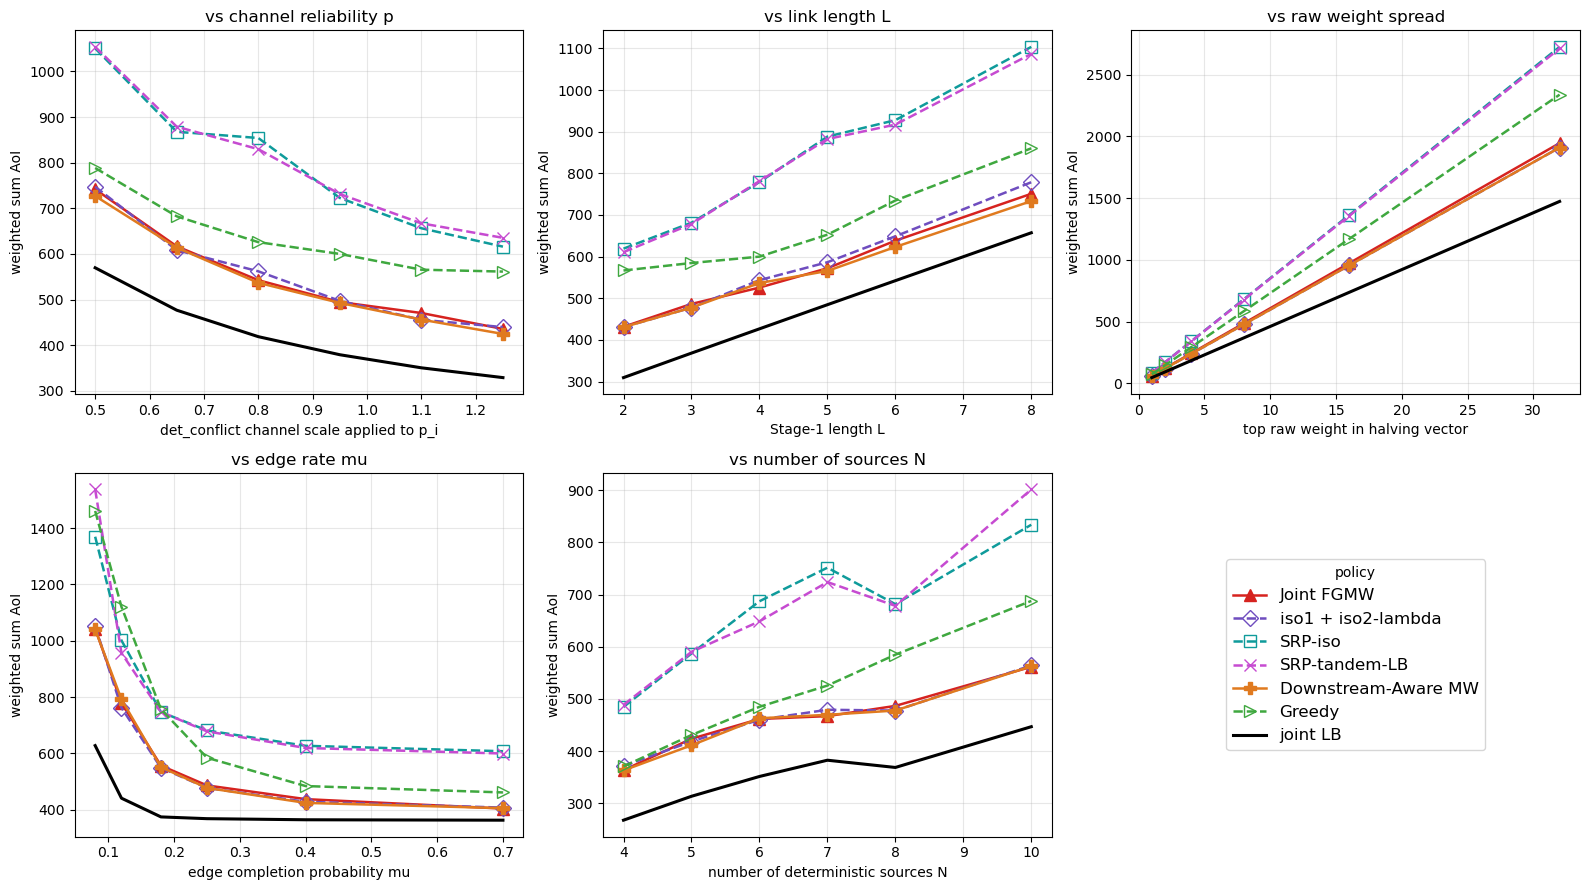

Section 8 uses deterministic raw unnormalized weights, the det_conflict channel pairing, and weighted destination AoI objectives compared against the joint/universal lower bound.

In [6]:
import json
from IPython.display import Markdown

SWEEP_POLICIES = [
    "Joint FGMW",
    "iso1 + iso2-lambda",
    "Downstream-Aware MW",
    "Greedy",
    "SRP-iso",
    "SRP-tandem-LB",
]
RECOMPUTE_SWEEPS = False

if RECOMPUTE_SWEEPS:
    RAW_DET_WEIGHTS = np.array([8.0, 4.0, 2.0, 1.0, 0.5, 0.25, 0.125, 0.0625], float)
    P_GOOD_TO_BAD = np.array([0.95, 0.85, 0.70, 0.55, 0.40, 0.28, 0.18, 0.10], float)
    BASE = dict(N=8, L=3, mu=0.25, top_weight=8.0, channel_scale=1.0)
    SWEEP_SPECS = {
        "p":  dict(xlabel="det_conflict channel scale applied to p_i", values=[0.5,0.65,0.8,0.95,1.1,1.25], key="channel_scale"),
        "L":  dict(xlabel="Stage-1 length L", values=[2,3,4,5,6,8], key="L"),
        "w":  dict(xlabel="top raw weight in halving vector", values=[1,2,4,8,16,32], key="top_weight"),
        "mu": dict(xlabel="edge completion probability mu", values=[0.08,0.12,0.18,0.25,0.4,0.7], key="mu"),
        "N":  dict(xlabel="number of deterministic sources N", values=[4,5,6,7,8,10], key="N"),
    }

    def _halving_weights(n, top=8.0):
        return np.array([float(top) / (2.0 ** i) for i in range(int(n))], float)

    def _p_levels_for_n(n):
        return P_GOOD_TO_BAD.copy() if int(n) == 8 else np.geomspace(0.95, 0.10, int(n))

    def _det_conflict_network(N, L, mu, top_weight, channel_scale):
        w = _halving_weights(int(N), top=top_weight)
        p = np.clip(float(channel_scale) * _p_levels_for_n(N)[::-1], 0.02, 1.0)
        return int(N), int(L), p, float(mu), w

    def run_sweep_v3(name, *, K=6_000, warmup=600, seeds=(0,), K_pilot=8_000, warmup_pilot=800, pilot_seeds=(100,)):
        spec = SWEEP_SPECS[name]
        out = {"x": [], "xlabel": spec["xlabel"], "policies": {k: [] for k in SWEEP_POLICIES}, "lb": []}
        for value in spec["values"]:
            cfg = dict(BASE); cfg[spec["key"]] = value
            n, l, pp, mm, ww = _det_conflict_network(**cfg)
            policies, params = build_experiment_v3(n, l, pp, mm, ww)
            lambda_est = estimate_iso1_voq_arrival_rates(n, l, pp, mm, ww, pilot_seeds=pilot_seeds, K_pilot=K_pilot, warmup_pilot=warmup_pilot)
            policies = dict(policies)
            policies["iso1 + iso2-lambda"] = build_iso1_iso2_lambda_policy_v3(n, l, pp, mm, ww, lambda_est["lambda_hat"])
            policies["SRP-iso"] = build_srp_iso_policy_v3(n, l, pp, mm, ww, lambda_est["lambda_hat"])
            policies["SRP-tandem-LB"] = build_srp_tandem_lb_policy_v3(n, l, pp, mm, ww, joint_params=params["joint"])
            out["x"].append(value); out["lb"].append(float(n * params["lb_dest_joint"]))
            for pol_name in SWEEP_POLICIES:
                vals = [float(n * TandemAoISimulatorV3(n, l, pp, mm, ww, seed=s).run(policies[pol_name], K=K, warmup=warmup)["weighted_dest_aoi"]) for s in seeds]
                out["policies"][pol_name].append(float(np.mean(vals)))
        return out
    SWEEP_V3 = {nm: run_sweep_v3(nm) for nm in SWEEP_SPECS}
else:
    SWEEP_V3 = json.loads(SWEEP_V3_JSON)

fig, axes = tandem_plotting.plot_sweep_grid(SWEEP_V3)
plt.show()
display(Markdown("Section 8 uses deterministic raw unnormalized weights, the det_conflict channel pairing, and weighted destination AoI objectives compared against the joint/universal lower bound."))


## 9. Deterministic aligned vs conflict comparison

This section loads `results/deterministic_heterogeneous_comparison.csv`, generated by `python experiments/deterministic_heterogeneous_comparison.py --quick` or `--full`. It uses the same raw, unnormalized weights as Section 8 and exactly two deterministic networks: `det_aligned`, where high-weight sources have good channels, and `det_conflict`, where high-weight sources have bad channels.

The isolated MW reference is `iso1 + iso2-lambda`. Greedy is the simple unweighted myopic baseline, DA-MW is target-rate-debt guided, Joint FGMW is certificate-guided, and the SRP baselines show the gap between stationary randomized policies and adaptive policies.


Loaded results/deterministic_heterogeneous_comparison.csv with 72 rows; mode(s): ['quick']


,network,policy,weighted_dest_aoi,gap_vs_iso_lambda_pct,stage1_used_frac,stage2_used_frac,stage2_idle_empty_frac,total_VOQ_arrival_rate,total_delivery_rate,total_overwrite_rate
5,det_aligned,iso1 + iso2-lambda,61.9760,0.0000,1.0000,0.7958,0.2042,0.2289,0.1798,0.0499
2,det_aligned,Joint FGMW,61.5907,-0.6295,1.0000,0.7899,0.2101,0.2285,0.1796,0.0498
0,det_aligned,Downstream-Aware MW,61.5304,-0.3827,1.0000,0.7747,0.2253,0.2260,0.1760,0.0510
1,det_aligned,Greedy,100.0146,62.7881,1.0000,0.6747,0.3253,0.1589,0.1444,0.0156
3,det_aligned,SRP-iso,82.5785,35.1033,1.0000,0.7747,0.2253,0.2248,0.1762,0.0483
4,det_aligned,SRP-tandem-LB,89.3307,43.2127,0.8570,0.7304,0.2696,0.1851,0.1693,0.0156
11,det_conflict,iso1 + iso2-lambda,73.9707,0.0000,1.0000,0.6281,0.3719,0.1426,0.1325,0.0112
8,det_conflict,Joint FGMW,74.4541,0.7476,1.0000,0.6289,0.3711,0.1409,0.1286,0.0127
6,det_conflict,Downstream-Aware MW,73.8971,-0.4363,1.0000,0.6272,0.3728,0.1388,0.1280,0.0116
7,det_conflict,Greedy,97.8787,28.8955,1.0000,0.6673,0.3327,0.1559,0.1420,0.0158


,network,L,corr_w_c,w,p
0,det_aligned,3,-0.5508,"[8.0, 4.0, 2.0, 1.0, 0.5, 0.25, 0.125, 0.0625]","[0.95, 0.85, 0.7, 0.55, 0.4, 0.28, 0.18, 0.1]"
18,det_aligned,5,-0.5508,"[8.0, 4.0, 2.0, 1.0, 0.5, 0.25, 0.125, 0.0625]","[0.95, 0.85, 0.7, 0.55, 0.4, 0.28, 0.18, 0.1]"
36,det_conflict,3,0.9989,"[8.0, 4.0, 2.0, 1.0, 0.5, 0.25, 0.125, 0.0625]","[0.1, 0.18, 0.28, 0.4, 0.55, 0.7, 0.85, 0.95]"
54,det_conflict,5,0.9989,"[8.0, 4.0, 2.0, 1.0, 0.5, 0.25, 0.125, 0.0625]","[0.1, 0.18, 0.28, 0.4, 0.55, 0.7, 0.85, 0.95]"


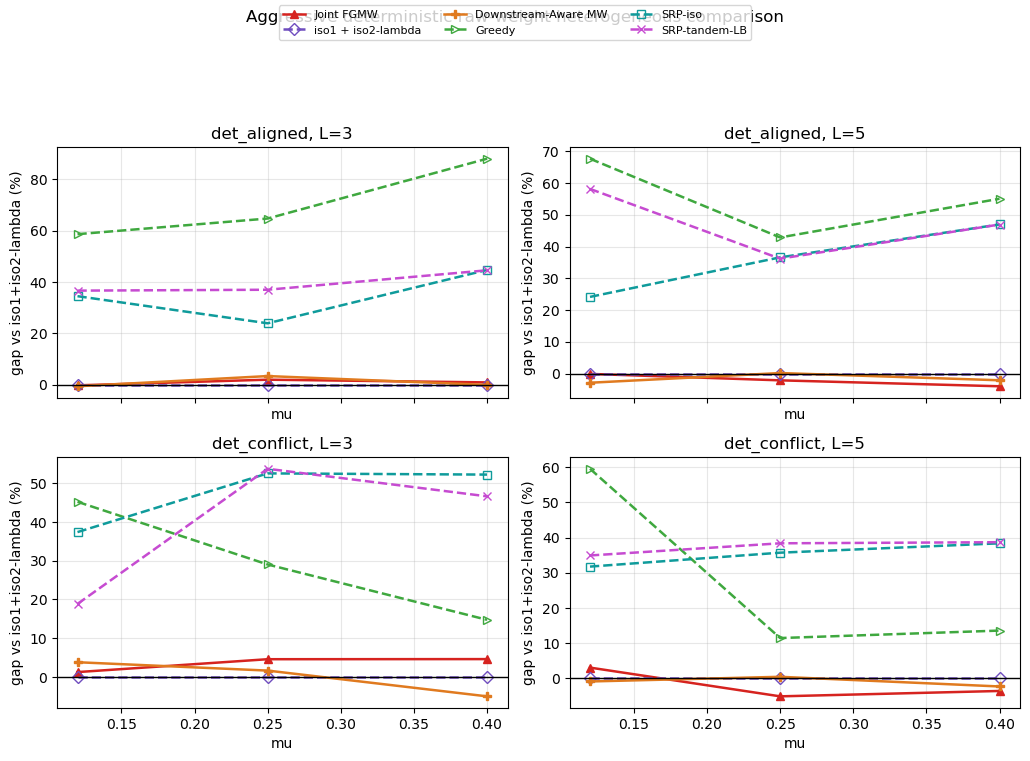

In [7]:
det_path = Path("results/deterministic_heterogeneous_comparison.csv")
if det_path.exists():
    det_df = pd.read_csv(det_path)
    print(f"Loaded {det_path} with {len(det_df)} rows; mode(s): {sorted(det_df['mode'].unique())}")
    det_policy_order = [
        "iso1 + iso2-lambda",
        "Joint FGMW",
        "Downstream-Aware MW",
        "Greedy",
        "SRP-iso",
        "SRP-tandem-LB",
    ]
    det_summary = (
        det_df.groupby(["network", "policy"])[[
            "weighted_dest_aoi",
            "gap_vs_iso_lambda_pct",
            "stage1_used_frac",
            "stage2_used_frac",
            "stage2_idle_empty_frac",
            "total_VOQ_arrival_rate",
            "total_delivery_rate",
            "total_overwrite_rate",
        ]]
        .mean()
        .reset_index()
    )
    det_summary["policy"] = pd.Categorical(det_summary["policy"], det_policy_order, ordered=True)
    det_summary = det_summary.sort_values(["network", "policy"])
    display(det_summary.round(4))

    det_corr = det_df[["network", "L", "corr_w_c", "w", "p"]].drop_duplicates().sort_values(["network", "L"])
    display(det_corr.round(4))

    fig, axes = tandem_plotting.plot_deterministic_heterogeneous_gap(det_df)
    plt.show()
else:
    print("Deterministic comparison CSV not found. Run: python experiments/deterministic_heterogeneous_comparison.py --quick or --full")


Raw weights are intentionally aggressive, and deterministic settings avoid random-sampling ambiguity. `det_aligned` is easier because important sources are cheap/easy to serve; `det_conflict` is harder because important sources are expensive/hard to serve. The comparison highlights how Greedy, DA-MW, Joint FGMW, lambda-aware isolated MW, and the SRP baselines respond to weight-channel mismatch.


## 9c. SRP-inclusive heterogeneous screening

This supplemental diagnostic compares stationary randomized policy baselines against the MW policies. `SRP-iso` combines the exact isolated Stage-1 SRP optimizer with the lambda-aware isolated Stage-2 SRP target. `SRP-tandem-LB` uses a single lower-bound-induced target rate vector for both Stage-1 refreshes and Stage-2 deliveries. The comparison tests whether that one-rate tandem SRP design is too restrictive in heterogeneous networks.

The notebook only loads `results/heterogeneous_screening_with_srp.csv` when it exists; it does not rerun the full SRP-inclusive screening grid.


Loaded results/heterogeneous_screening_with_srp.csv with 28 rows; mode(s): ['quick']


,policy,alignment,weighted_dest_aoi,gap_vs_iso_lambda_pct,stage2_idle_empty_frac,total_VOQ_arrival_rate,total_delivery_rate,total_overwrite_rate
8,iso1 + iso2-lambda,aligned,38.9262,0.0000,0.1906,0.2556,0.1833,0.0706
9,iso1 + iso2-lambda,conflict,43.9871,0.0000,0.2600,0.1911,0.1506,0.0411
2,Joint FGMW,aligned,39.7154,1.5889,0.2133,0.2511,0.1772,0.0706
3,Joint FGMW,conflict,43.7058,-0.7136,0.2844,0.2044,0.1489,0.0539
0,Greedy,aligned,44.3339,10.2402,0.2022,0.2500,0.1789,0.0689
1,Greedy,conflict,48.8460,10.4827,0.3178,0.1600,0.1333,0.0256
4,SRP-iso,aligned,53.9083,41.4520,0.2272,0.2378,0.1711,0.0633
5,SRP-iso,conflict,57.1923,31.9363,0.2628,0.1889,0.1478,0.0389
6,SRP-tandem-LB,aligned,56.5518,46.2347,0.2883,0.1772,0.1661,0.0089
7,SRP-tandem-LB,conflict,65.0733,45.2625,0.3478,0.1517,0.1400,0.0100


,alignment,policy,gap_vs_iso_lambda_pct,srp_alpha_sum,srp_beta_sum,srp_stage1_target_sum,srp_stage2_target_sum,total_VOQ_arrival_rate,total_delivery_rate,total_overwrite_rate,stage2_idle_empty_frac
0,aligned,SRP-iso,41.4520,1.0000,0.8130,0.2378,0.1852,0.2378,0.1711,0.0633,0.2272
1,aligned,SRP-tandem-LB,46.2347,0.7030,0.7974,0.1790,0.1790,0.1772,0.1661,0.0089,0.2883
2,conflict,SRP-iso,31.9363,1.0000,0.7481,0.1825,0.1593,0.1889,0.1478,0.0389,0.2628
3,conflict,SRP-tandem-LB,45.2625,0.8221,0.7285,0.1514,0.1514,0.1517,0.1400,0.0100,0.3478


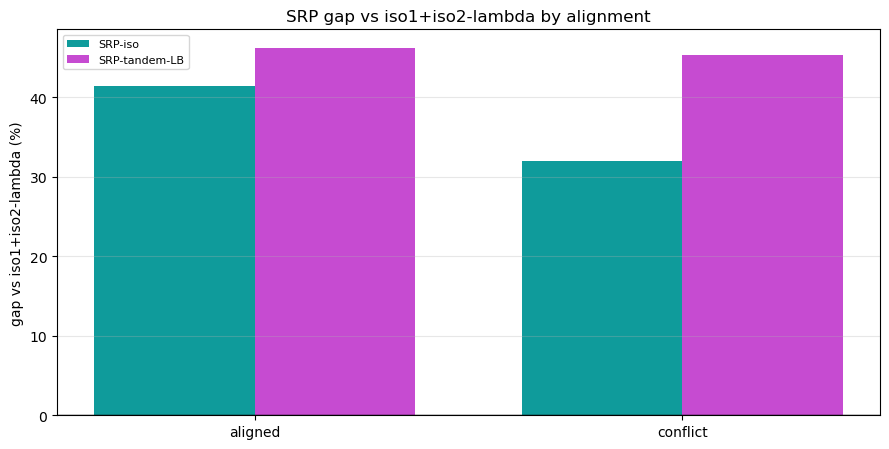

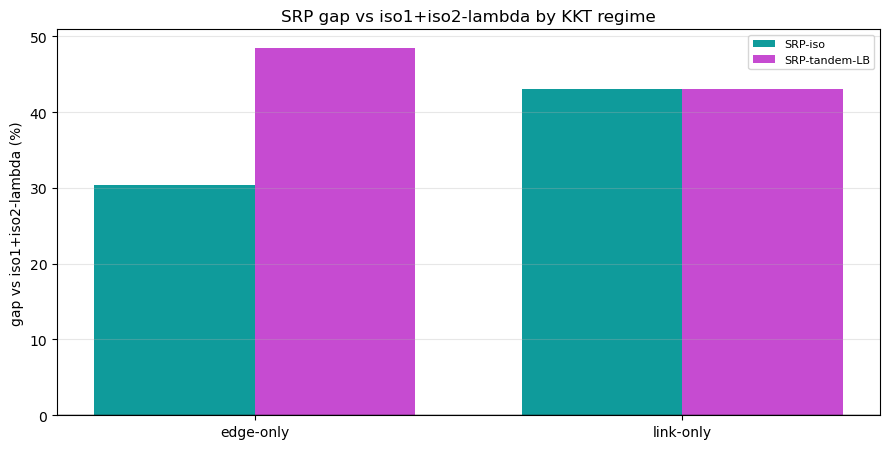

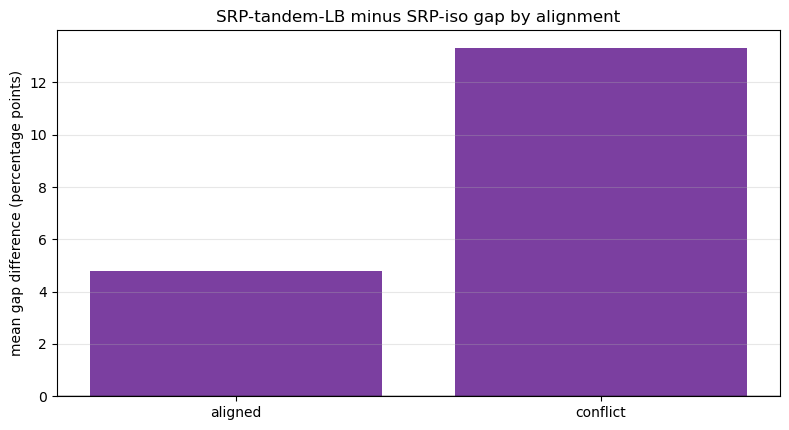

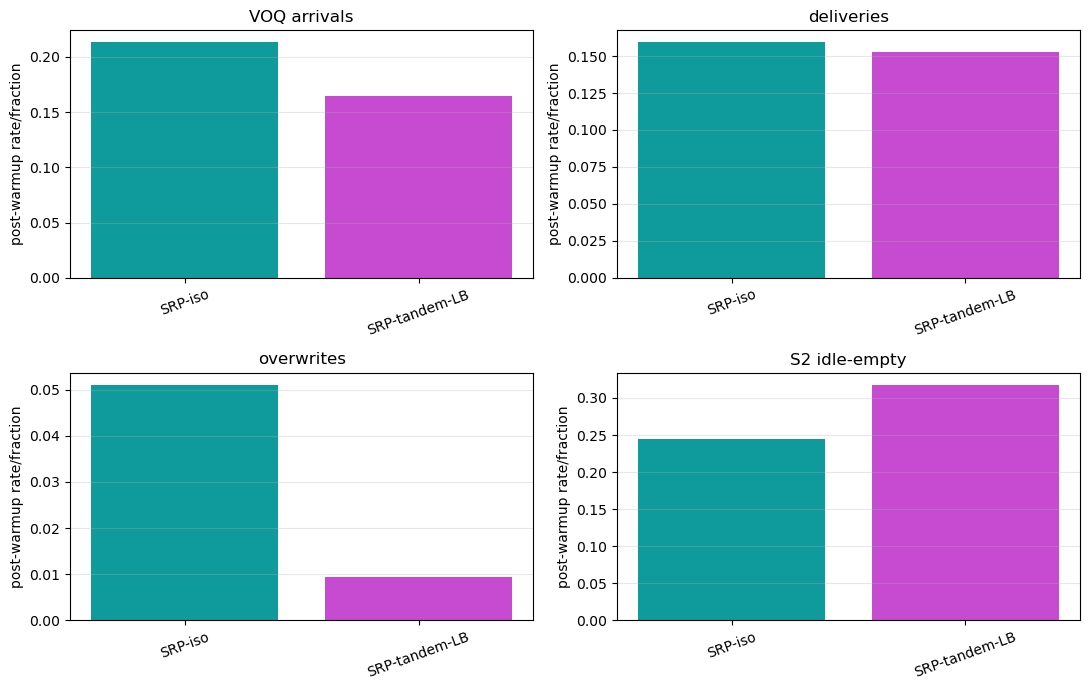

In [8]:
from pathlib import Path

srp_screening_path = Path("results/heterogeneous_screening_with_srp.csv")
srp_policy_order = [
    "iso1 + iso2-lambda",
    "Joint FGMW",
    "Downstream-Aware MW",
    "Greedy",
    "SRP-iso",
    "SRP-tandem-LB",
]
srp_summary_metrics = [
    "weighted_dest_aoi",
    "gap_vs_iso_lambda_pct",
    "stage2_idle_empty_frac",
    "total_VOQ_arrival_rate",
    "total_delivery_rate",
    "total_overwrite_rate",
]
srp_only_metrics = [
    "gap_vs_iso_lambda_pct",
    "srp_alpha_sum",
    "srp_beta_sum",
    "srp_stage1_target_sum",
    "srp_stage2_target_sum",
    "total_VOQ_arrival_rate",
    "total_delivery_rate",
    "total_overwrite_rate",
    "stage2_idle_empty_frac",
]

if srp_screening_path.exists():
    srp_screening_df = pd.read_csv(srp_screening_path)
    print(f"Loaded {srp_screening_path} with {len(srp_screening_df)} rows; mode(s): {sorted(srp_screening_df['screening_mode'].unique())}")

    present_policies = [p for p in srp_policy_order if p in set(srp_screening_df["policy"])]
    srp_high_level = (
        srp_screening_df[srp_screening_df["policy"].isin(present_policies)]
        .groupby(["policy", "alignment"])[srp_summary_metrics]
        .mean()
        .reset_index()
    )
    srp_high_level["policy"] = pd.Categorical(srp_high_level["policy"], present_policies, ordered=True)
    srp_high_level = srp_high_level.sort_values(["policy", "alignment"])
    display(srp_high_level.round(4))

    srp_only = (
        srp_screening_df[srp_screening_df["policy"].isin(["SRP-iso", "SRP-tandem-LB"])]
        .groupby(["alignment", "policy"])[srp_only_metrics]
        .mean()
        .reset_index()
        .sort_values(["alignment", "policy"])
    )
    display(srp_only.round(4))

    fig, ax = tandem_plotting.plot_srp_iso_vs_tandem_gap_by_alignment(srp_screening_df)
    plt.show()

    fig, ax = tandem_plotting.plot_srp_iso_vs_tandem_gap_by_regime(srp_screening_df)
    plt.show()

    fig, ax = tandem_plotting.plot_srp_tandem_minus_iso_gap(srp_screening_df)
    plt.show()

    fig, axes = tandem_plotting.plot_srp_pipeline_diagnostics(srp_screening_df)
    plt.show()
else:
    print("Run python experiments/heterogeneous_screening_with_srp.py --quick or --full first.")


If `SRP-tandem-LB` is worse than `SRP-iso`, this does not mean joint optimization is useless. The current tandem SRP is a one-rate lower-bound-induced design: it uses the same target rate vector for Stage-1 refreshes and Stage-2 deliveries. In AoI systems, upstream refresh rate and downstream delivery rate may need to differ because VOQ overwriting can keep packets fresh. This motivates a future two-rate tandem SRP design, but that design is not implemented here.


## 10. Secondary systematic heterogeneous screening

This diagnostic loads the broader screening CSV when available. It is kept secondary because the main paper figures above use deterministic raw-weight networks. The notebook does not recompute the full grid; run `python experiments/heterogeneous_screening.py --full` from the repository root to regenerate the screen.


Loaded results/heterogeneous_screening.csv with 540 rows; mode(s): ['full']


,screening_mode,policy,weighted_dest_aoi,weighted_dest_aoi_se,corr_w_c,weight_ratio,alignment,L,mu,lambda_link,...,weight_seed,channel_seed,K,warmup,num_seeds,pilot_K,pilot_warmup,num_pilot_seeds,gap_vs_iso_pct,gap_vs_iso_lambda_pct
0,full,Joint FGMW,76.6282,1.3841,-0.8489,10.0,aligned,3,0.08,0.0,...,7,11,10000,1000,3,20000,2000,3,0.0247,0.0247
1,full,iso1 + iso2,76.6093,1.6714,-0.8489,10.0,aligned,3,0.08,0.0,...,7,11,10000,1000,3,20000,2000,3,0.0000,0.0000
2,full,iso1 + iso2-lambda,76.6093,1.6714,-0.8489,10.0,aligned,3,0.08,0.0,...,7,11,10000,1000,3,20000,2000,3,0.0000,0.0000
3,full,Greedy,84.9435,1.7409,-0.8489,10.0,aligned,3,0.08,0.0,...,7,11,10000,1000,3,20000,2000,3,10.8788,10.8788
4,full,Uniform,107.1419,2.2304,-0.8489,10.0,aligned,3,0.08,0.0,...,7,11,10000,1000,3,20000,2000,3,39.8549,39.8549
5,full,Joint FGMW,54.3001,0.8044,-0.8489,10.0,aligned,3,0.12,0.0,...,7,11,10000,1000,3,20000,2000,3,0.3600,0.2377
6,full,iso1 + iso2,54.1053,0.7741,-0.8489,10.0,aligned,3,0.12,0.0,...,7,11,10000,1000,3,20000,2000,3,0.0000,-0.1219
7,full,iso1 + iso2-lambda,54.1714,0.7775,-0.8489,10.0,aligned,3,0.12,0.0,...,7,11,10000,1000,3,20000,2000,3,0.1221,0.0000
8,full,Greedy,62.6420,0.8838,-0.8489,10.0,aligned,3,0.12,0.0,...,7,11,10000,1000,3,20000,2000,3,15.7779,15.6368
9,full,Uniform,74.6549,1.4078,-0.8489,10.0,aligned,3,0.12,0.0,...,7,11,10000,1000,3,20000,2000,3,37.9807,37.8125


,policy,alignment,mean,min,max,count
0,Greedy,aligned,14.0250,-0.8122,31.2216,36
1,Greedy,conflict,14.6835,4.2760,22.8667,36
2,Greedy,neutral,12.6714,2.5590,24.1781,36
3,Joint FGMW,aligned,-0.2515,-2.5432,2.0235,36
4,Joint FGMW,conflict,-0.7568,-3.3195,1.7098,36
5,Joint FGMW,neutral,-0.6017,-4.2509,4.0210,36


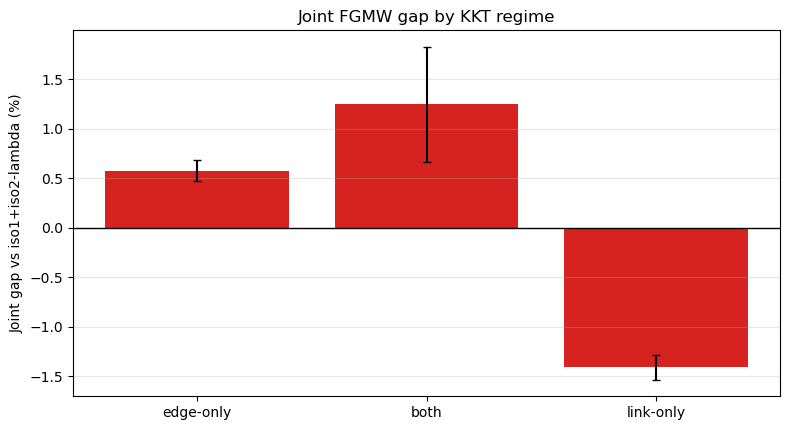

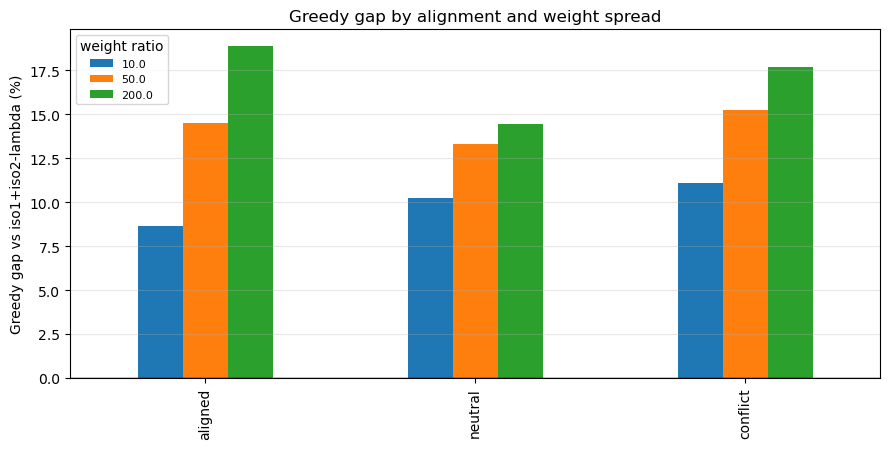

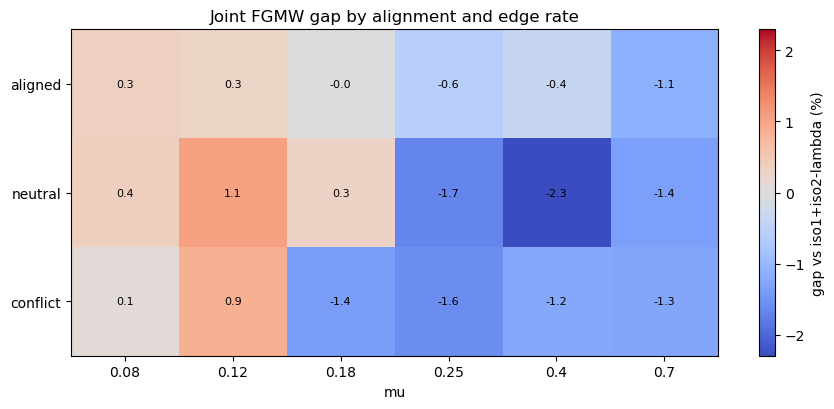

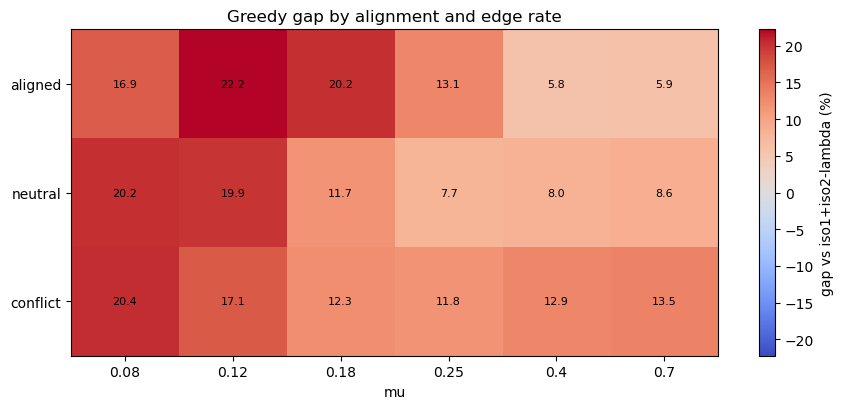

In [9]:
from pathlib import Path

screening_path = Path("results/heterogeneous_screening.csv")
if screening_path.exists():
    screening_df = pd.read_csv(screening_path)
    print(f"Loaded {screening_path} with {len(screening_df)} rows; mode(s): {sorted(screening_df['screening_mode'].unique())}")
    display(screening_df.head(15).round(4))
    screening_summary = (
        screening_df[screening_df["policy"].isin(["Joint FGMW", "Greedy"])]
        .groupby(["policy", "alignment"])["gap_vs_iso_lambda_pct"]
        .agg(["mean", "min", "max", "count"])
        .reset_index()
    )
    display(screening_summary.round(4))

    fig, ax = tandem_plotting.plot_screening_joint_gap_by_regime(screening_df)
    plt.show()

    fig, ax = tandem_plotting.plot_screening_greedy_gap_by_alignment(screening_df)
    plt.show()

    fig, ax = tandem_plotting.plot_screening_joint_heatmap(screening_df)
    plt.show()

    fig, ax = tandem_plotting.plot_screening_greedy_heatmap(screening_df)
    plt.show()
else:
    print("Screening CSV not found. Run: python experiments/heterogeneous_screening.py --full")


## Appendix A. Secondary paired-seed binding-regime diagnostic

This older paired-seed diagnostic is retained for checking how the Joint FGMW versus isolated-MW gap changes across KKT binding regimes. It is useful context, but it is not the main paper-facing figure.

Two heterogeneous configurations are swept in $\mu$ across edge-bound, both-multipliers-positive, and link-bound regimes. For every $\mu$, Joint FGMW and iso1+iso2 are run under common random numbers over 6 paired seeds. Embedded results render immediately; set `RECOMPUTE_HETERO=True` only when intentionally regenerating the diagnostic.


In [10]:
HETERO_V3_JSON = r'''{"A": {"name": "A: p=[.9,.7,.4,.2], w=[1,2,4,8]", "N": 4, "L": 3, "p": [0.9, 0.7, 0.4, 0.2], "w": [1.0, 2.0, 4.0, 8.0], "mu": [0.12, 0.15, 0.18, 0.2, 0.21, 0.25, 0.3], "regime": ["edge", "edge", "edge", "both", "link", "link", "link"], "lam_link": [0.0, 0.0, 0.0, 4.11472390036397, 113.8594285059662, 119.06766986864386, 122.80715911480365], "nu_edge": [1542.389340345282, 992.9717208375223, 693.6328583231661, 544.0352435444947, 0.0, 0.0, 0.0], "joint": {"0.12": [533.2677777777777, 530.5426222222222, 532.4148888888889, 534.2049333333333, 532.9376444444445, 540.4688888888888], "0.15": [443.6978222222222, 443.45511111111114, 441.8820888888889, 436.5335111111111, 444.0749777777778, 447.1372], "0.18": [380.4496888888889, 384.3796888888889, 383.8031555555556, 375.76377777777776, 383.33182222222223, 384.9981333333333], "0.2": [349.62555555555554, 356.57635555555555, 353.19395555555553, 347.95644444444446, 353.92266666666666, 354.2486666666667], "0.21": [331.4467111111111, 341.1520888888889, 338.4954222222222, 333.6296888888889, 341.63306666666665, 338.8547111111111], "0.25": [296.0117333333333, 304.02004444444447, 297.01866666666666, 298.7010222222222, 301.8710222222222, 301.00124444444447], "0.3": [268.33195555555557, 272.5592, 266.28648888888887, 270.55084444444446, 270.74426666666665, 271.4136]}, "iso": {"0.12": [535.9437333333333, 528.2157333333333, 529.3453777777778, 528.5462666666666, 533.3696888888888, 538.9207111111111], "0.15": [445.2960444444444, 441.01315555555556, 441.5316888888889, 434.7458222222222, 445.55724444444445, 447.0570222222222], "0.18": [380.58706666666666, 381.6640888888889, 383.9373777777778, 375.2993333333333, 384.06857777777776, 385.09128888888887], "0.2": [350.6725777777778, 353.5778222222222, 354.11684444444444, 346.2150222222222, 353.80431111111113, 353.59093333333334], "0.21": [336.7050222222222, 339.6891111111111, 340.39875555555557, 335.2927555555556, 341.39324444444446, 340.7727111111111], "0.25": [298.3699111111111, 305.9004888888889, 299.24875555555553, 298.33973333333336, 301.0625333333333, 302.2133777777778], "0.3": [270.15813333333335, 272.86075555555556, 268.80173333333335, 271.07737777777777, 272.13662222222223, 273.32466666666664]}}, "B": {"name": "B: p=[.95,.8,.6,.35,.2,.1], w=[1,1,2,4,6,10]", "N": 6, "L": 3, "p": [0.95, 0.8, 0.6, 0.35, 0.2, 0.1], "w": [1.0, 1.0, 2.0, 4.0, 6.0, 10.0], "mu": [0.1, 0.13, 0.15, 0.17, 0.2, 0.25, 0.3], "regime": ["edge", "edge", "both", "link", "link", "link", "link"], "lam_link": [0.0, 0.0, 83.00851269220584, 373.5071836014977, 379.97000333771575, 385.9083141902229, 389.0458234871039], "nu_edge": [5607.199887709692, 3326.9527297532186, 1969.854141346179, 0.0, 0.0, 0.0, 0.0], "joint": {"0.1": [1306.6707111111573, 1295.715111111094, 1287.1419111110922, 1289.7133333333484, 1292.5579555555744, 1312.2590222222561], "0.13": [1060.0520000000042, 1040.9027111111068, 1062.6846666666506, 1059.3900444444444, 1060.9332444444317, 1072.8692444444687], "0.15": [945.682622222221, 929.5808000000056, 934.4759111111109, 930.2873777777565, 944.8308888889028, 951.2692888888922], "0.17": [845.9832888888827, 833.5605777777791, 835.0383555555572, 833.4747111111201, 853.6568444444397, 842.3005777777853], "0.2": [762.4331999999956, 748.0637777777581, 753.694577777777, 750.2075555555597, 771.440755555552, 751.5067999999907], "0.25": [675.0597777777738, 670.7798222222173, 676.5586222222155, 677.6762666666775, 692.7191111110975, 682.8728888888666], "0.3": [646.3914222222244, 629.2837333333155, 633.3884444444438, 629.1382666666836, 637.7376888888863, 635.6423111111023]}, "iso": {"0.1": [1298.8642666666094, 1278.0698666666667, 1269.7649777777847, 1272.6463111110868, 1270.8692000000374, 1296.4826222222107], "0.13": [1053.0187999999923, 1018.860622222219, 1035.80377777779, 1032.4394666666701, 1042.6083999999923, 1053.2706666666463], "0.15": [941.0322222222014, 920.2757777777599, 920.1076888888997, 915.4819999999945, 932.1192444444541, 934.1295111111144], "0.17": [854.8195111111306, 839.1824444444264, 839.599066666668, 837.1294222222135, 851.7916888888859, 848.189600000004], "0.2": [770.0971555555574, 748.0906666666532, 761.2412444444496, 756.2247111111012, 768.0159999999776, 760.075155555557], "0.25": [687.7878222222271, 671.5972888888836, 675.3417777777798, 682.7514222222139, 684.7311111110812, 679.747599999996], "0.3": [646.898711111114, 626.6713777777878, 633.1068000000031, 644.1451111111138, 640.6037777777626, 635.9252444444551]}}}'''

Config A: A: p=[.9,.7,.4,.2], w=[1,2,4,8]  (6 paired seeds, common random numbers)
     mu regime  lam_lnk   nu_edg         joint     iso1+iso2       diff(J-I)
   0.12   edge     0.00   1542.4    534.0+-2.7    532.4+-3.5      1.58+-2.31
   0.15   edge     0.00    993.0    442.8+-2.8    442.5+-3.6      0.26+-1.32
   0.18   edge     0.00    693.6    382.1+-2.8    381.8+-2.9      0.35+-0.98
    0.2   both     4.11    544.0    352.6+-2.6    352.0+-2.5      0.59+-1.26
   0.21   link   113.86      0.0    337.5+-3.3    339.0+-2.0     -1.51+-1.83
   0.25   link   119.07      0.0    299.8+-2.4    300.9+-2.3     -1.09+-1.09
    0.3   link   122.81      0.0    270.0+-1.8    271.4+-1.4     -1.41+-0.68  significant

Config B: B: p=[.95,.8,.6,.35,.2,.1], w=[1,1,2,4,6,10]  (6 paired seeds, common random numbers)
     mu regime  lam_lnk   nu_edg         joint     iso1+iso2       diff(J-I)
    0.1   edge     0.00   5607.2   1297.3+-8.0   1281.1+-10.5     16.23+-3.67  significant
   0.13   edge     0.00

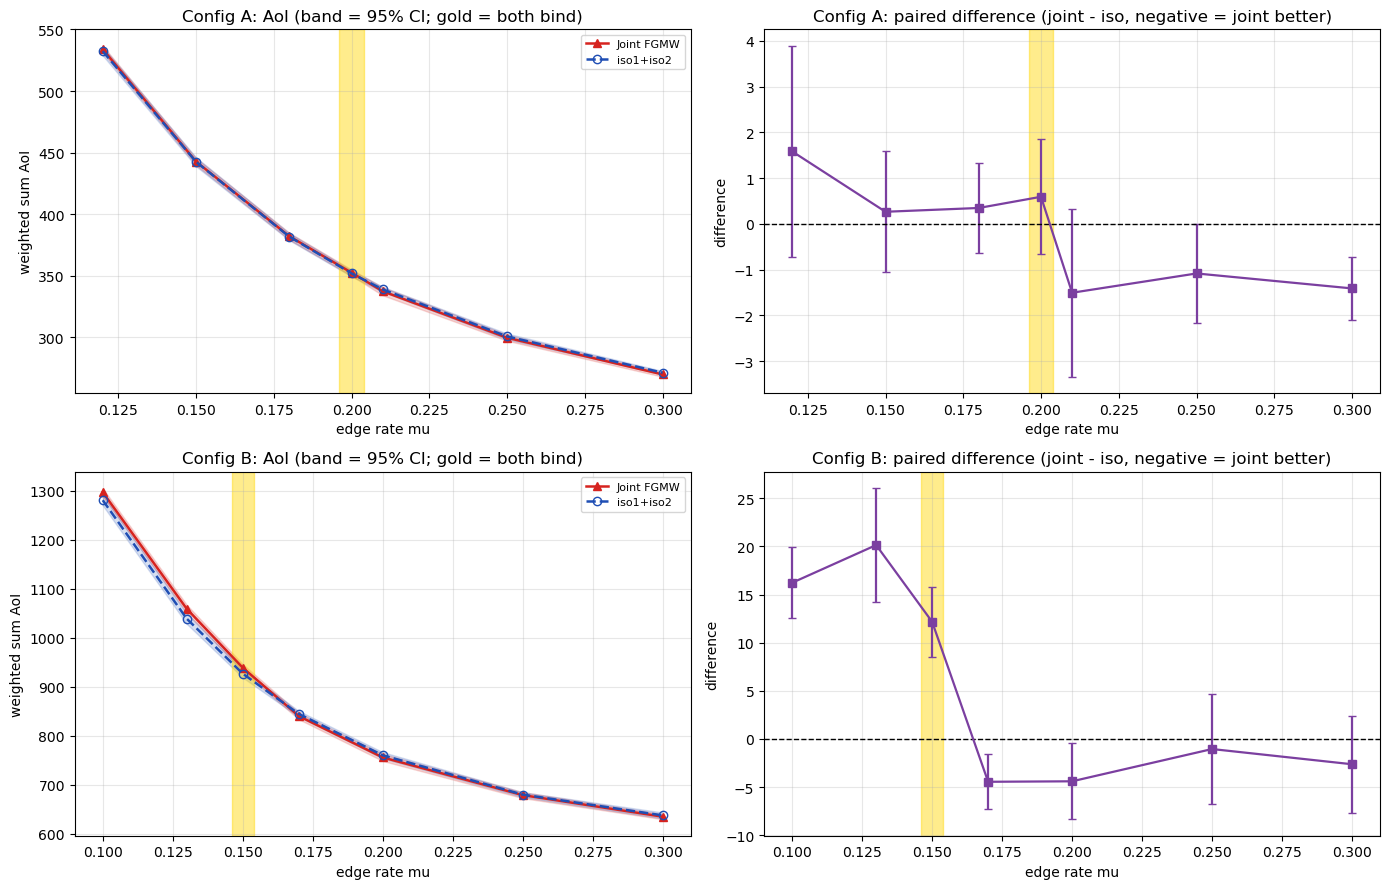

In [11]:
HV = json.loads(HETERO_V3_JSON)

RECOMPUTE_HETERO = False
if RECOMPUTE_HETERO:
    def _regime(J):
        d = J["dual"]
        return "both" if (d["lambda_link"] > 1e-6 and d["nu_edge"] > 1e-6) else ("edge" if d["nu_edge"] > 1e-6 else "link")
    def _sweep_cfg(name, N, L, p, w, mus, seeds=range(6), K=25_000, warm=2_500):
        out = dict(name=name, N=N, L=L, p=list(p), w=list(w), mu=list(mus),
                   regime=[], lam_link=[], nu_edge=[], joint={}, iso={})
        for mu in mus:
            J = joint_params_v3(N, L, p, mu, w); out["regime"].append(_regime(J))
            out["lam_link"].append(float(J["dual"]["lambda_link"])); out["nu_edge"].append(float(J["dual"]["nu_edge"]))
            pols, _ = build_experiment_v3(N, L, p, mu, w)
            out["joint"][f"{mu}"] = [float(N * TandemAoISimulatorV3(N, L, p, mu, w, seed=s).run(pols["Joint FGMW"], K, warm)["weighted_dest_aoi"]) for s in seeds]
            out["iso"][f"{mu}"]  = [float(N * TandemAoISimulatorV3(N, L, p, mu, w, seed=s).run(pols["iso1 + iso2"], K, warm)["weighted_dest_aoi"]) for s in seeds]
        return out
    HV = {"A": _sweep_cfg("A: p=[.9,.7,.4,.2], w=[1,2,4,8]", 4, 3, [0.9,0.7,0.4,0.2], [1.,2.,4.,8.], [0.12,0.15,0.18,0.20,0.21,0.25,0.30]),
          "B": _sweep_cfg("B: p=[.95,.8,.6,.35,.2,.1], w=[1,1,2,4,6,10]", 6, 3, [0.95,0.80,0.60,0.35,0.20,0.10], [1.,1.,2.,4.,6.,10.], [0.10,0.13,0.15,0.17,0.20,0.25,0.30])}

def _ci(a):
    a = np.asarray(a, float); return a.mean(), 1.96 * a.std(ddof=1) / np.sqrt(len(a))

for key in ["A", "B"]:
    d = HV[key]; nseed = len(d["joint"][f"{d['mu'][0]}"])
    print(f"Config {key}: {d['name']}  ({nseed} paired seeds, common random numbers)")
    print(f"  {'mu':>5}{'regime':>7}{'lam_lnk':>9}{'nu_edg':>9}{'joint':>14}{'iso1+iso2':>14}{'diff(J-I)':>16}")
    for k, mu in enumerate(d["mu"]):
        jm, je = _ci(d["joint"][f"{mu}"]); im, ie = _ci(d["iso"][f"{mu}"])
        dd = np.array(d["joint"][f"{mu}"]) - np.array(d["iso"][f"{mu}"]); dm, de = _ci(dd)
        sig = "  significant" if abs(dm) > de else ""
        print(f"  {mu:>5}{d['regime'][k]:>7}{d['lam_link'][k]:>9.2f}{d['nu_edge'][k]:>9.1f}"
              f"{jm:>9.1f}+-{je:<3.1f}{im:>9.1f}+-{ie:<3.1f}{dm:>10.2f}+-{de:<4.2f}{sig}")
    print()

fig, axes = tandem_plotting.plot_heterogeneous_binding_regimes(HV, _ci)
plt.show()


## Appendix B. Minimal regression sanity checks

These checks are kept out of the main figure flow. They verify an exact one-source trajectory, randomized KKT feasibility, Stage-1 path independence from the Stage-2 controller under separated RNG streams, post-warmup accounting, and the structural bridge.


In [12]:
class AlwaysServeOneSource:
    def decide(self, sim):
        u_bs = 0 if sim.B == -1 else -1
        u_es = 0 if sim.J == -1 and sim.V[0] else -1
        return u_bs, u_es


def run_regression_tests():
    # Exact deterministic one-source cycles under the notebook's +2 reset convention.
    for L in (1, 2, 3, 5):
        r = TandemAoISimulatorV3(1, L, [1.0], 1.0, [1.0], seed=1).run(
            AlwaysServeOneSource(), K=500, warmup=50, validate=True
        )
        np.testing.assert_allclose(r["weighted_bsside_age"], 1.5 * L - 0.5, atol=1e-12)
        np.testing.assert_allclose(r["weighted_dest_aoi"], 1.5 * L + 1.5, atol=1e-12)

    # Heterogeneous KKT stress test.
    rng = np.random.default_rng(4)
    for _ in range(60):
        N = int(rng.integers(1, 12))
        L = int(rng.integers(2, 10))
        p = np.exp(rng.uniform(np.log(0.02), 0.0, N))
        mu = float(np.exp(rng.uniform(np.log(0.02), 0.0)))
        w = np.exp(rng.uniform(np.log(0.05), np.log(50.0), N))
        c = L - 1.0 + 1.0 / p
        g = w * (1.0 - mu) / mu**2
        q, _ = solve_rate_kkt(w, g, link_c=c, edge_cap=mu)
        assert c @ q <= 1.0 + 1e-9
        assert q.sum() <= mu + 1e-9
        assert np.all(q > 0.0)

    # Stage-1 evolution must not depend on the Stage-2 controller.
    N, L, p, mu, w = 6, 3, [0.6] * 6, 0.6, [1, 1, 1, 4, 4, 4]
    policies, _ = build_experiment_v3(N, L, p, mu, w)
    r_mw = TandemAoISimulatorV3(N, L, p, mu, w, seed=8).run(
        policies["iso1 + iso2"], K=3000, warmup=0, record_series=True
    )
    r_srp = TandemAoISimulatorV3(N, L, p, mu, w, seed=8).run(
        policies["iso1 + WC-SRP2"], K=3000, warmup=0, record_series=True
    )
    np.testing.assert_array_equal(r_mw["series"]["Aq"], r_srp["series"]["Aq"])

    # Anchor accounting and structural invariant.
    K, warmup = 10_000, 1_000
    r = TandemAoISimulatorV3(N, L, p, mu, w, seed=0).run(
        policies["Joint FGMW"], K=K, warmup=warmup, validate=True
    )
    validate_run_result(r, K, L)
    assert r["max_bridge_violation"] <= 1e-10
    assert r["s1_used_frac"] <= 1.0 + 1e-12
    assert r["s2_used_frac"] <= 1.0 + 1e-12

    print("All tandem regression tests passed.")


run_regression_tests()


All tandem regression tests passed.


## Interpretation checklist

1. Treat Section 8 and the deterministic aligned/conflict comparison as the main simulation story.
2. Use `iso1 + iso2-lambda` as the primary isolated-MW reference in deterministic figures.
3. Interpret Greedy as a simple unweighted myopic baseline, DA-MW as target-rate-debt guided, and Joint FGMW as certificate-guided.
4. Use `SRP-iso` and `SRP-tandem-LB` to separate stationary randomized baselines from adaptive policies.
5. Keep secondary screening and binding-regime diagnostics as robustness/context checks rather than the notebook headline.
